In [1]:
import sys

In [2]:
%%capture
try:
    # Attempt to import a module that's only available in Colab
    from google.colab import drive

    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    # Colab specific setup
    drive.mount("/content/drive")
    sys.path.append("/content/drive/MyDrive/structure-loss-classification/")
    my_local_data = "/content/drive/MyDrive/types/"
    %cd '/content/drive/MyDrive/structure-loss-classification/'
    %pip install -r requirements.txt
else:
    # Local machine setup
    my_local_data = "/mnt/g/My Drive/types/"

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay
import torchvision.transforms as transforms
import torch
from sklearn.model_selection import train_test_split

In [4]:
import pickle

In [5]:
from models.models import LeNet5, ResNet18
from lightning_modules.lightning_modules import LitLeNet5, LitResNet18, LitVGG16
from visualization.filters import display_filters
from visualization.display import process_plot_image, display_metrics
from datasets.data_modules import CustomImageDataModule
from train.train import get_features, train_model, train_with_cv
from hyperparameter_tuning.tune import HyperParameterTuner
from datasets.datasets import CustomDatasetWrapper
from utils.utils import load_targets, get_stat_metrics, get_train_val_data

In [6]:
from ray import tune

In [7]:
toTensorAndNormalize = transforms.Compose(
    [
        transforms.Resize((244, 244)),
        transforms.RandomHorizontalFlip(),
        # transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # mean  # std
    ]
)

In [8]:
classification_mode = "all"

In [9]:
task = {"binary": 2, "only_bad": 3, "all": 4}

In [10]:
num_classes = task[classification_mode]

In [11]:
aux_data = CustomDatasetWrapper(
    root_dir=my_local_data,
    classification_mode=classification_mode,
    transform=toTensorAndNormalize,
)

In [12]:
datamodule = CustomImageDataModule(dataset=aux_data)

In [13]:
model_class = LitLeNet5

In [14]:
trainer_config = {
    "patience": 10,
    "accelerator": "gpu",
    "devices": -1,
    "max_epochs": 200,
    "precision": 32,
    "n_steps": 50,
}

torch.set_float32_matmul_precision('high')

save_dir = f'logdir/pipeline_1/{model_class.__name__}/{classification_mode}/cv'

In [15]:
search_space = {
   'model_params': {"num_classes": num_classes,
                    "size_layer_1": tune.choice([100, 84, 50]),
                    "size_layer_2": tune.choice([30, 20, 10]),
                    "learning_rate": tune.loguniform(1e-4, 1e-2)},
   
    "batch_size": tune.choice([32, 64, 128]),
}

default_config = {
    'num_classes': num_classes,
    'learning_rate': 0.001
}

In [16]:
# Try to load cached targets first
targets = load_targets(aux_data)

In [22]:
my_tuner = HyperParameterTuner(model_class = model_class,
                                   datamodule = datamodule,
                                   search_space = search_space,
                                   num_samples = 8,
                                   num_epochs = 10)

In [18]:
torch.cuda.device_count()

0

In [19]:
my_tuner.resources

{'num_cpus': 8, 'num_gpus': 0}

In [23]:
params = my_tuner.hypertune()

2024-03-21 00:03:29,426	WARNING insufficient_resources_manager.py:163 -- Ignore this message if the cluster is autoscaling. No trial is running and no new trial has been started within the last 60 seconds. This could be due to the cluster not having enough resources available. You asked for 9.0 CPUs and 0 GPUs per trial, but the cluster only has 8.0 CPUs and 0 GPUs available. Stop the tuning and adjust the required resources (e.g. via the `ScalingConfig` or `resources_per_trial`, or `num_workers` for rllib), or add more resources to your cluster.
2024-03-21 00:04:10,161	WARNING tune.py:186 -- Stop signal received (e.g. via SIGINT/Ctrl+C), ending Ray Tune run. This will try to checkpoint the experiment state one last time. Press CTRL+C (or send SIGINT/SIGKILL/SIGTERM) to skip. 
2024-03-21 00:04:10,181	INFO tune.py:1047 -- Total run time: 101.13 seconds (101.09 seconds for the tuning loop).
2024-03-21 00:04:10,182	WARNING tune.py:1062 -- Experiment has been interrupted, but the most rece

RuntimeError: No best trial found for the given metric: val_accuracy. This means that no trial has reported this metric, or all values reported for this metric are NaN. To not ignore NaN values, you can set the `filter_nan_and_inf` arg to False.

In [21]:
import ray
ray.shutdown()

In [12]:
# Assuming aux_data is a dataset object and targets are the labels
train_data, val_data = get_train_val_data(aux_data, targets)

In [14]:
aux_data.classes

['goodIngots', 'typeA', 'typeB', 'typeC']

### Test train

In [16]:
torch.set_float32_matmul_precision("medium")

In [17]:
from train.train import incremental_training

In [18]:
model_class = LitVGG16

In [19]:
model_params = {
    "num_classes": num_classes,
    "size_layer_1": 128,
    "size_layer_2": 64,
    "size_layer_3": 32,
    "learning_rate": 8.479282111072422e-05,
}

In [20]:
trainer_config = {
    "patience": 50,
    "accelerator": "gpu",
    "devices": -1,
    # "max_epochs": 100,
    "precision": 32,
    "n_steps": 5,
    "save_dir": f"logdir/LitVGG16/{classification_mode}",
}

In [21]:
# metrics = incremental_training(
#     model_class=model_class,
#     model_params=model_params,
#     trainer_config=trainer_config,
#     data_module=data_module,
#     early_stop_patience=5,

# )

In [22]:
from torchvision.models.feature_extraction import get_graph_node_names

In [23]:
from models.models import ResNet18

In [24]:
model = LeNet5(
    num_classes=num_classes,
)
model = model.to("cuda")

In [25]:
# get_graph_node_names(model)[0]

In [26]:
# layers = [e for e in get_graph_node_names(model)[0] if 'pool' in e]
layers = [
    "convStack.1",
    "convStack.2",
    "convStack.3",
]

In [27]:
features, labels = get_features(
    model=model,
    layers=layers,
    data_loader=aux_data,
    device="cuda",
    classification_mode=classification_mode,
)

Attempting to load cached features and labels...
Loaded features and labels from cache.


In [28]:
import matplotlib.pyplot as plt

In [29]:
from visualization.filters import display_filters

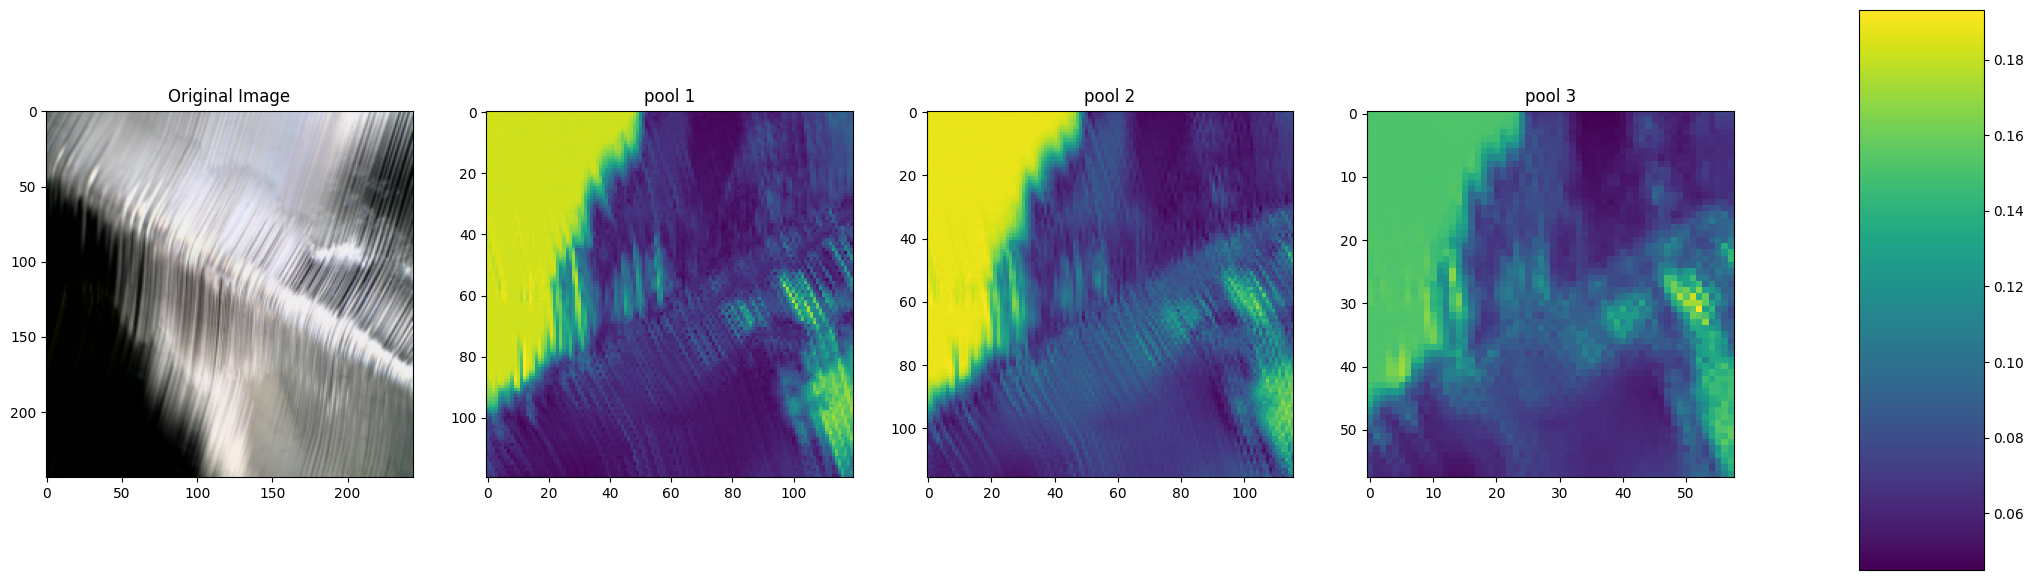

In [30]:
display_filters(
    features=features,
    img_num=33,
    layers=layers,
    cmap="viridis",
    name_layers=["pool 1", "pool 2", "pool 3"],
    data=aux_data,
)

In [31]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [32]:
import numpy as np

In [33]:
new_features = {}

In [34]:
for layer_name in features:
    new_features[layer_name] = [feature.flatten() for feature in features[layer_name]]

In [35]:
hp_sweep = {
    "kernel": "rbf",
    "C": 3.2010661148711947,
    "gamma": "scale",
}

In [36]:
from hyperparameter_tuning.tune import hypertune_classifier, SKLearnHyperParameterTuner

In [37]:
param_grid = {
    'kernel': tune.choice(['linear', 'poly', 'rbf', 'sigmoid']),
    'C': tune.loguniform(1e-3, 1e3),
    'gamma': tune.choice(['scale', 'auto']),
}

In [38]:
X = np.array(new_features[layers[1]])
y = np.array(labels)

In [39]:
my_tuner = SKLearnHyperParameterTuner(model = SVC,
                                      search_space = param_grid,
                                      X= X,
                                      y = y,
                                      use_gpu=False)

2024-03-15 15:51:12,639	INFO worker.py:1664 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


In [ ]:
best_params = my_tuner.hypertune()

In [ ]:
best_params

In [ ]:
import ray

In [ ]:
ray.shutdown()

In [ ]:
ray.init(resources={'num_cpus':12, 'num_gpus':1})

In [ ]:
torch.cuda.is_available()

In [ ]:
print(ray.cluster_resources())

In [ ]:
# Use the first layer's features in this example
X = np.array(features[layers[hp_sweep["features_index"]]])
y = np.array(labels)

# Initialize the 5-fold cross-validator
cv = StratifiedKFold(n_splits=5)

# Create an SVC with an RBF kernel
# svc = SVC(kernel=hp_sweep['kernel'],
#           C=hp_sweep['C'],
#           gamma=hp_sweep['gamma'])

svc = SVC()

# Initialize an empty confusion matrix to store the summary of all folds
summary_confusion_matrix = np.zeros((len(np.unique(y)), len(np.unique(y))))
accuracies = []

In [ ]:
aux_data.classes

In [ ]:
names_dict = {
    "typeA": "Diameter\nFluctuations",
    "typeB": "Node Cut",
    "typeC": "Particle Hit",
    "goodIngots": "No Structure\nLoss",
}

# Get class indices from the ImageFolder
class_indices = aux_data.classes

# Order your names list according to the class indices
names = [names_dict[class_name] for class_name in aux_data.classes]

In [19]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
dfs = []

In [21]:
for folder in sorted(glob.glob("logdir/all/lightning_logs/*")):
    df = pd.read_csv(f"{folder}/metrics.csv")
    dfs.append(df)

In [22]:
dfs

[   val_f1_score  epoch  val_loss  val_accuracy  step
 0      0.313726      0  1.349338      0.313726     6
 1      0.313726      1  1.492826      0.313726    13
 2      0.313726      2  1.516947      0.313726    20
 3      0.274510      3  1.327109      0.274510    27
 4      0.509804      4  1.124067      0.509804    34,
    val_f1_score  epoch  val_loss  val_accuracy  step
 0      0.549020      5  1.050494      0.549020    41
 1      0.705882      6  0.950057      0.705882    48
 2      0.627451      7  0.962080      0.627451    55
 3      0.647059      8  0.973073      0.647059    62
 4      0.705882      9  0.875689      0.705882    69,
    val_f1_score  epoch  val_loss  val_accuracy  step
 0      0.725490     10  0.826381      0.725490    76
 1      0.647059     11  0.846321      0.647059    83
 2      0.764706     12  0.778082      0.764706    90
 3      0.666667     13  0.847053      0.666667    97
 4      0.725490     14  0.773270      0.725490   104,
    val_f1_score  epoch  

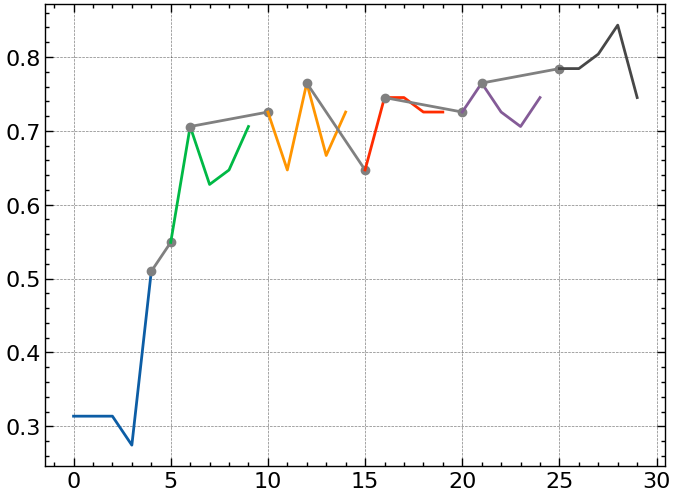

In [23]:
for c, df in enumerate(dfs):
    # Plot the main line with markers
    plt.plot(df.epoch, df.val_accuracy, '-', label=str(c+1))

    # Find the index of the maximum val_accuracy in the current dataframe
    max_val_acc_index = df.val_accuracy.idxmax()

    # If this is not the last dataframe, draw a dotted line to the first point of the next dataframe
    if c < len(dfs) - 1:
        next_df = dfs[c + 1]
        # Get the point with max val_accuracy from the current dataframe and the first point of the next dataframe
        x_values = [df.epoch.iloc[max_val_acc_index], next_df.epoch.iloc[0]]
        y_values = [df.val_accuracy.iloc[max_val_acc_index], next_df.val_accuracy.iloc[0]]
        # Plot with dotted lines
        plt.plot(x_values, y_values, 'o-', color='grey')

# plt.legend()
plt.show()


In [1]:
dir_pre = "/mnt/g/My Drive/structure-loss-classification/results/LitResNet18/"
dir_not = (
    "/mnt/g/My Drive/structure-loss-classification/results/LitResNet18-not-pretrained"
)

In [2]:
from visualization.display import compare_resnet18

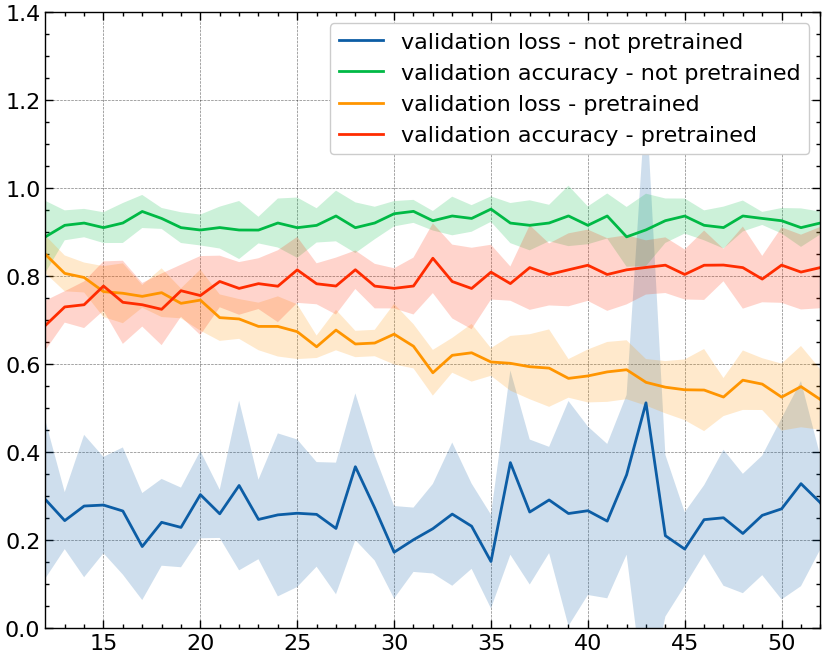

In [3]:
compare_resnet18("only_bad")

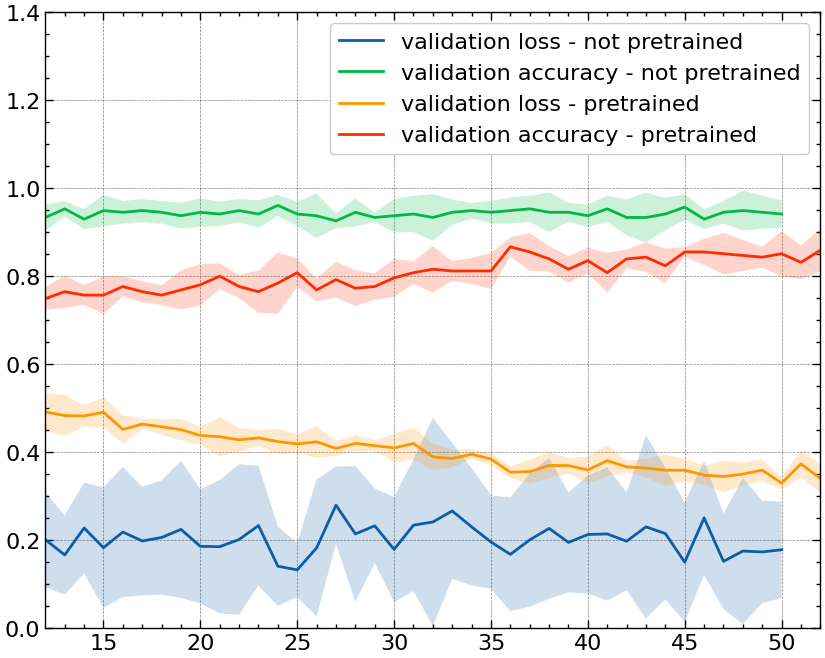

In [4]:
compare_resnet18("binary")

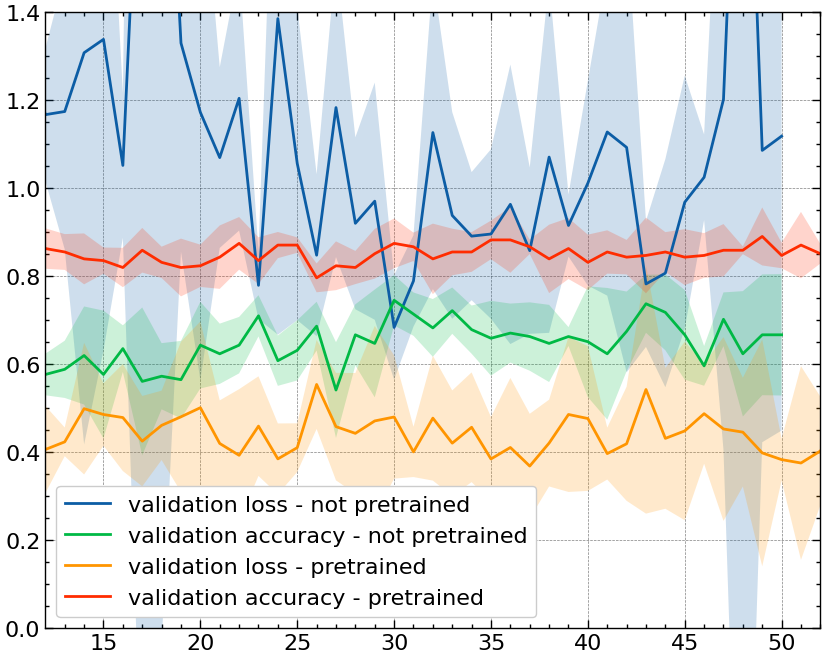

In [5]:
compare_resnet18("all")